# hw4 - NN pyTorch

Во всем задании вы должны работать со входом из строк размером (длиной) 1024

## Часть 1 Фурье

### Подготовка данных

Сгенерите данные (сигнал) любым пакетом для численного преобразования Фурье, [например](https://numpy.org/doc/stable/reference/generated/numpy.fft.fft.html#numpy.fft.fft)

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy import signal
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim

np.random.seed(17)
torch.manual_seed(17)

In [2]:
# Параметры
N = 1000
BATCH_SIZE = 32
SIGNAL_LENGTH = 1024
DEVICE = torch.device("cpu")


# Генерирует сигнал (сумма синусоид с разными частотами)
def generate_signal(length=SIGNAL_LENGTH, num_components=5):
    t = np.linspace(0, 1, length)
    signal = np.zeros(length)

    for _ in range(num_components):
        freq = np.random.uniform(1, 50)  # Частота
        amplitude = np.random.uniform(0.5, 2.0)  # Амплитуда
        phase = np.random.uniform(0, 2 * np.pi)  # Фаза
        signal += amplitude * np.sin(2 * np.pi * freq * t + phase)

    # Шум
    noise = np.random.normal(0, 0.1, length)
    signal += noise

    return signal.astype(np.float32)


X_train = np.array([generate_signal() for _ in range(N)])
y_train = np.array([np.fft.fft(x) for x in X_train])

y_train_real = y_train.real.astype(np.float32)  # Действительная часть
y_train_imag = y_train.imag.astype(np.float32)  # Мнимая часть

y_train_combined = np.stack([y_train_real, y_train_imag], axis=1)

print(f"Форма X_train: {X_train.shape}")
print(f"Форма y_train_combined: {y_train_combined.shape}")

Форма X_train: (1000, 1024)
Форма y_train_combined: (1000, 2, 1024)


### Соберите и обучите нейросетку на pyTroch для преобразования Фурье

In [3]:
# Обучаем модель
def train_model(
    model,
    data_loader,
    loss_function,
    optimizer,
    n_epochs,
    device,
):
    model.to(device)
    model.train()
    training_metrics = []

    for epoch in range(n_epochs):
        cumulative_loss = 0.0
        progress_indicator = tqdm(data_loader, desc=f"Эпоха {epoch+1}/{n_epochs}")

        for temporal_inputs, spectral_targets in progress_indicator:
            temporal_inputs = temporal_inputs.to(device)
            spectral_targets = spectral_targets.to(device)

            optimizer.zero_grad()

            predicted_spectra = model(temporal_inputs)

            optimization_loss = loss_function(predicted_spectra, spectral_targets)

            optimization_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            current_loss = optimization_loss.item()
            cumulative_loss += current_loss
            progress_indicator.set_postfix({"текущая ошибка": current_loss})

        average_epoch_loss = cumulative_loss / len(data_loader)
        training_metrics.append(average_epoch_loss)
        print(f"Средняя ошибка: {average_epoch_loss:.6f}")

    return training_metrics


Модель FourierTransformer:
Общее количество параметров: 39,884,800

Запуск процедуры обучения...


Эпоха 1/25: 100%|██████████| 32/32 [00:05<00:00,  5.52it/s, текущая ошибка=2.26e+3]


Средняя ошибка: 2202.724003


Эпоха 2/25: 100%|██████████| 32/32 [00:05<00:00,  5.76it/s, текущая ошибка=2.04e+3]


Средняя ошибка: 2128.518173


...

Средняя ошибка: 820.819662


Эпоха 24/25: 100%|██████████| 32/32 [00:05<00:00,  5.65it/s, текущая ошибка=814]


Средняя ошибка: 779.328447


Эпоха 25/25: 100%|██████████| 32/32 [00:05<00:00,  5.59it/s, текущая ошибка=883]


Средняя ошибка: 745.941069


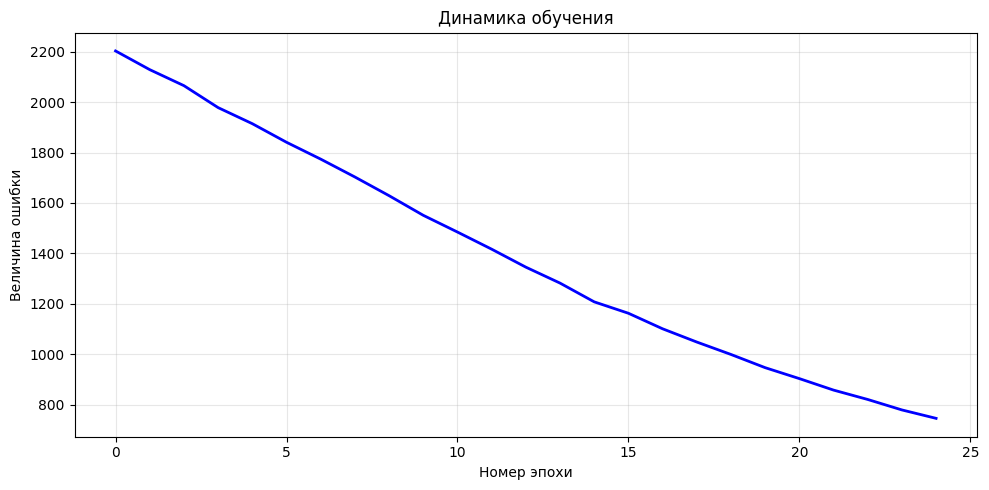


Финальная ошибка: 745.941069
Улучшение за обучение: 66.1%


In [4]:
class FourierTransformer(nn.Module):
    def __init__(self, input_size=SIGNAL_LENGTH, output_size=1024):
        super().__init__()

        self.feature_extractor = nn.Sequential(
            nn.Linear(input_size, 2048),
            nn.LeakyReLU(0.1),
            nn.BatchNorm1d(2048),
            nn.Dropout(0.25),
            nn.Linear(2048, 4096),
            nn.ELU(),
            nn.BatchNorm1d(4096),
            nn.Dropout(0.25),
            nn.Linear(4096, 4096),
            nn.SiLU(),
            nn.BatchNorm1d(4096),
            nn.Dropout(0.25),
            nn.Linear(4096, 2048),
            nn.ReLU(),
            nn.BatchNorm1d(2048),
            nn.Dropout(0.25),
            nn.Linear(2048, 2 * output_size),
        )

    def forward(self, input_signal):
        spectral_output = self.feature_extractor(input_signal)
        batch_size = input_signal.size(0)
        return spectral_output.view(batch_size, 2, -1)


class FourierTrainingData(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, index):
        return self.X[index], self.y[index]


model = FourierTransformer().to(DEVICE)
training_dataset = FourierTrainingData(X_train, y_train_combined)
data_loader = DataLoader(training_dataset, batch_size=BATCH_SIZE, shuffle=True)

loss_function = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)

print(f"\nМодель FourierTransformer:")
print(
    f"Общее количество параметров: " f"{sum(p.numel() for p in model.parameters()):,}"
)
print("\nЗапуск процедуры обучения...")

TOTAL_TRAINING_EPOCHS = 25
performance_history = train_model(
    model,
    data_loader,
    loss_function,
    optimizer,
    TOTAL_TRAINING_EPOCHS,
    DEVICE,
)

plt.figure(figsize=(10, 5))

plt.plot(performance_history, "b-", linewidth=2)
plt.xlabel("Номер эпохи")
plt.ylabel("Величина ошибки")
plt.title("Динамика обучения")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nФинальная ошибка: {performance_history[-1]:.6f}")
print(
    f"Улучшение за обучение: "
    f"{(performance_history[0] - performance_history[-1])/performance_history[0]*100:.1f}%"
)

### Сравните свое решение с пакетным методом

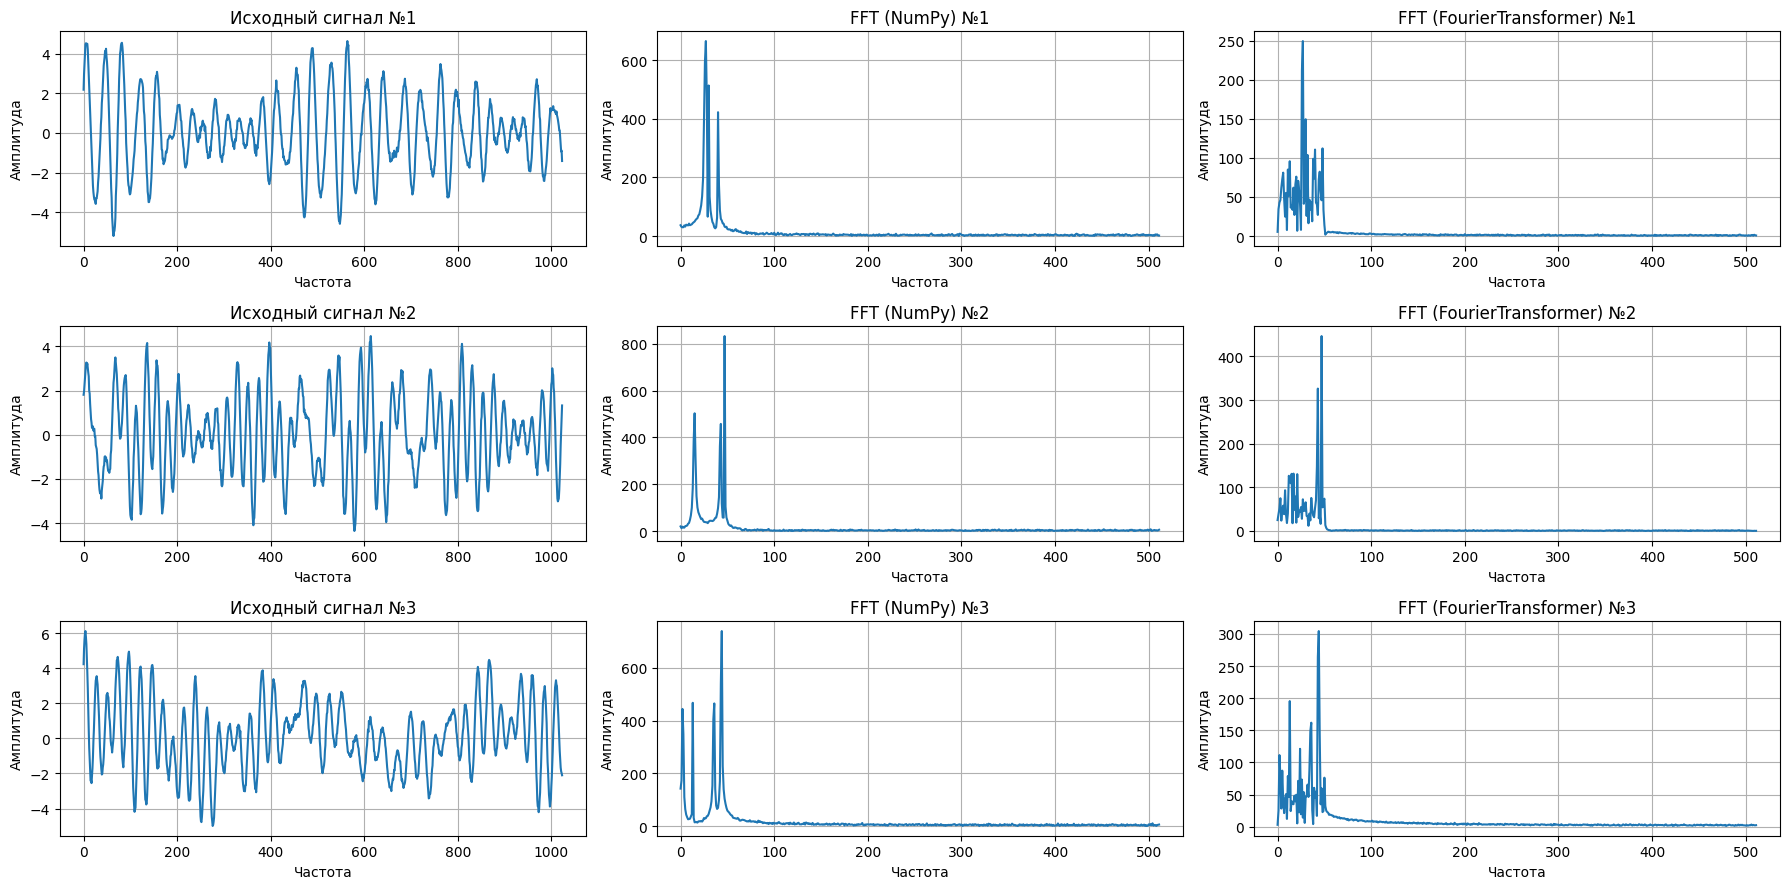


Сравнение FFT: NumPy vs FourierTransformer

Тестовый сигнал №1:
  MSE (действительная часть): 1286.8879
  MSE (мнимая часть): 996.3842
  MSE (амплитудный спектр): 1957.5469
  MAE (действительная часть): 8.8461
  MAE (мнимая часть): 8.8978
  MAE (амплитудный спектр): 8.1616
  Корреляция (амплитудный спектр): 0.763358

Тестовый сигнал №2:
  MSE (действительная часть): 551.8527
  MSE (мнимая часть): 871.9738
  MSE (амплитудный спектр): 1124.4395
  MAE (действительная часть): 6.0366
  MAE (мнимая часть): 8.6222
  MAE (амплитудный спектр): 5.7843
  Корреляция (амплитудный спектр): 0.881175

Тестовый сигнал №3:
  MSE (действительная часть): 1154.3091
  MSE (мнимая часть): 872.9285
  MSE (амплитудный спектр): 1615.7837
  MAE (действительная часть): 9.0443
  MAE (мнимая часть): 8.1071
  MAE (амплитудный спектр): 7.8153
  Корреляция (амплитудный спектр): 0.894761

Средние метрики:
  Средний MSE (действительная часть): 997.6833
  Средний MSE (мнимая часть): 913.7621
  Средний MAE (действительна

In [5]:
# Сравним на 3 сгенерированных сигналах
n_test = 3
test_signals = np.array([generate_signal() for _ in range(n_test)])

model.eval()
with torch.no_grad():
    test_tensor = torch.tensor(test_signals, dtype=torch.float32).to(DEVICE)
    predictions = model(test_tensor).cpu().numpy()

# Вычисляем FFT с помощью Numpy
fft_numpy = np.array([np.fft.fft(sig) for sig in test_signals])

fig, axes = plt.subplots(n_test, 3, figsize=(18, 3 * n_test))

for i in range(n_test):
    # Амплитудный спектр от Numpy FFT
    fft_magnitude_numpy = np.abs(fft_numpy[i])

    # Амплитудный спектр от FourierTransformer
    fft_nn = predictions[i][0] + 1j * predictions[i][1]
    fft_magnitude_nn = np.abs(fft_nn)

    axes[i, 0].plot(test_signals[i])
    axes[i, 0].set_title(f"Исходный сигнал №{i+1}")
    axes[i, 0].set_xlabel("Частота")
    axes[i, 0].set_ylabel("Амплитуда")
    axes[i, 0].grid(True)

    axes[i, 1].plot(fft_magnitude_numpy[: SIGNAL_LENGTH // 2])
    axes[i, 1].set_title(f"FFT (NumPy) №{i+1}")
    axes[i, 1].set_xlabel("Частота")
    axes[i, 1].set_ylabel("Амплитуда")
    axes[i, 1].grid(True)

    axes[i, 2].plot(fft_magnitude_nn[: SIGNAL_LENGTH // 2])
    axes[i, 2].set_title(f"FFT (FourierTransformer) №{i+1}")
    axes[i, 2].set_xlabel("Частота")
    axes[i, 2].set_ylabel("Амплитуда")
    axes[i, 2].grid(True)

plt.tight_layout()
plt.show()

print("\nСравнение FFT: NumPy vs FourierTransformer\n")
for i in range(n_test):
    fft_nn = predictions[i][0] + 1j * predictions[i][1]

    # MSE между действительными частями
    mse_real = np.mean((fft_numpy[i].real - predictions[i][0]) ** 2)

    # MSE между мнимыми частями
    mse_imag = np.mean((fft_numpy[i].imag - predictions[i][1]) ** 2)

    # MSE для амплитудных спектров
    mse_magnitude = np.mean((np.abs(fft_numpy[i]) - np.abs(fft_nn)) ** 2)

    # MAE между действительными частями
    mae_real = np.mean(np.abs(fft_numpy[i].real - predictions[i][0]))

    # MAE между мнимыми частями
    mae_imag = np.mean(np.abs(fft_numpy[i].imag - predictions[i][1]))

    # MAE для амплитудных спектров
    mae_magnitude = np.mean(np.abs(fft_numpy[i]) - np.abs(fft_nn))

    # Корреляция между амплитудными спектрами
    correlation = np.corrcoef(np.abs(fft_numpy[i]), np.abs(fft_nn))[0, 1]

    print(f"Тестовый сигнал №{i+1}:")
    print(f"  MSE (действительная часть): {mse_real:.4f}")
    print(f"  MSE (мнимая часть): {mse_imag:.4f}")
    print(f"  MSE (амплитудный спектр): {mse_magnitude:.4f}")
    print(f"  MAE (действительная часть): {mae_real:.4f}")
    print(f"  MAE (мнимая часть): {mae_imag:.4f}")
    print(f"  MAE (амплитудный спектр): {mae_magnitude:.4f}")
    print(f"  Корреляция (амплитудный спектр): {correlation:.6f}")
    print()

# Среднее по всем тестовым сигналам
avg_mse_real = np.mean(
    [np.mean((fft_numpy[i].real - predictions[i][0]) ** 2) for i in range(n_test)]
)
avg_mse_imag = np.mean(
    [np.mean((fft_numpy[i].imag - predictions[i][1]) ** 2) for i in range(n_test)]
)
avg_mae_real = np.mean(
    [np.mean(fft_numpy[i].real - predictions[i][0]) for i in range(n_test)]
)
avg_mae_imag = np.mean(
    [np.mean(fft_numpy[i].imag - predictions[i][1]) for i in range(n_test)]
)
avg_correlation = np.mean(
    [
        np.corrcoef(
            np.abs(fft_numpy[i]), np.abs(predictions[i][0] + 1j * predictions[i][1])
        )[0, 1]
        for i in range(n_test)
    ]
)

print(f"Средние метрики:")
print(f"  Средний MSE (действительная часть): {avg_mse_real:.4f}")
print(f"  Средний MSE (мнимая часть): {avg_mse_imag:.4f}")
print(f"  Средний MAE (действительная часть): {avg_mae_real:.4f}")
print(f"  Средний MAE (мнимая часть): {avg_mae_imag:.4f}")
print(f"  Средняя корреляция (амплитудный спектр): {avg_correlation:.6f}")

## Часть 2 Power spectral density (dB)

### Подготовка данных

Используя пакетное решение, [например](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.periodogram.html), подготовьте обучающую выборку.

Генерация обучающей выборки для PSD...
Форма X_train_psd: (5000, 1024)
Форма y_train_psd: (5000, 513)

Длина входа: 1024
Длина выхода: 513


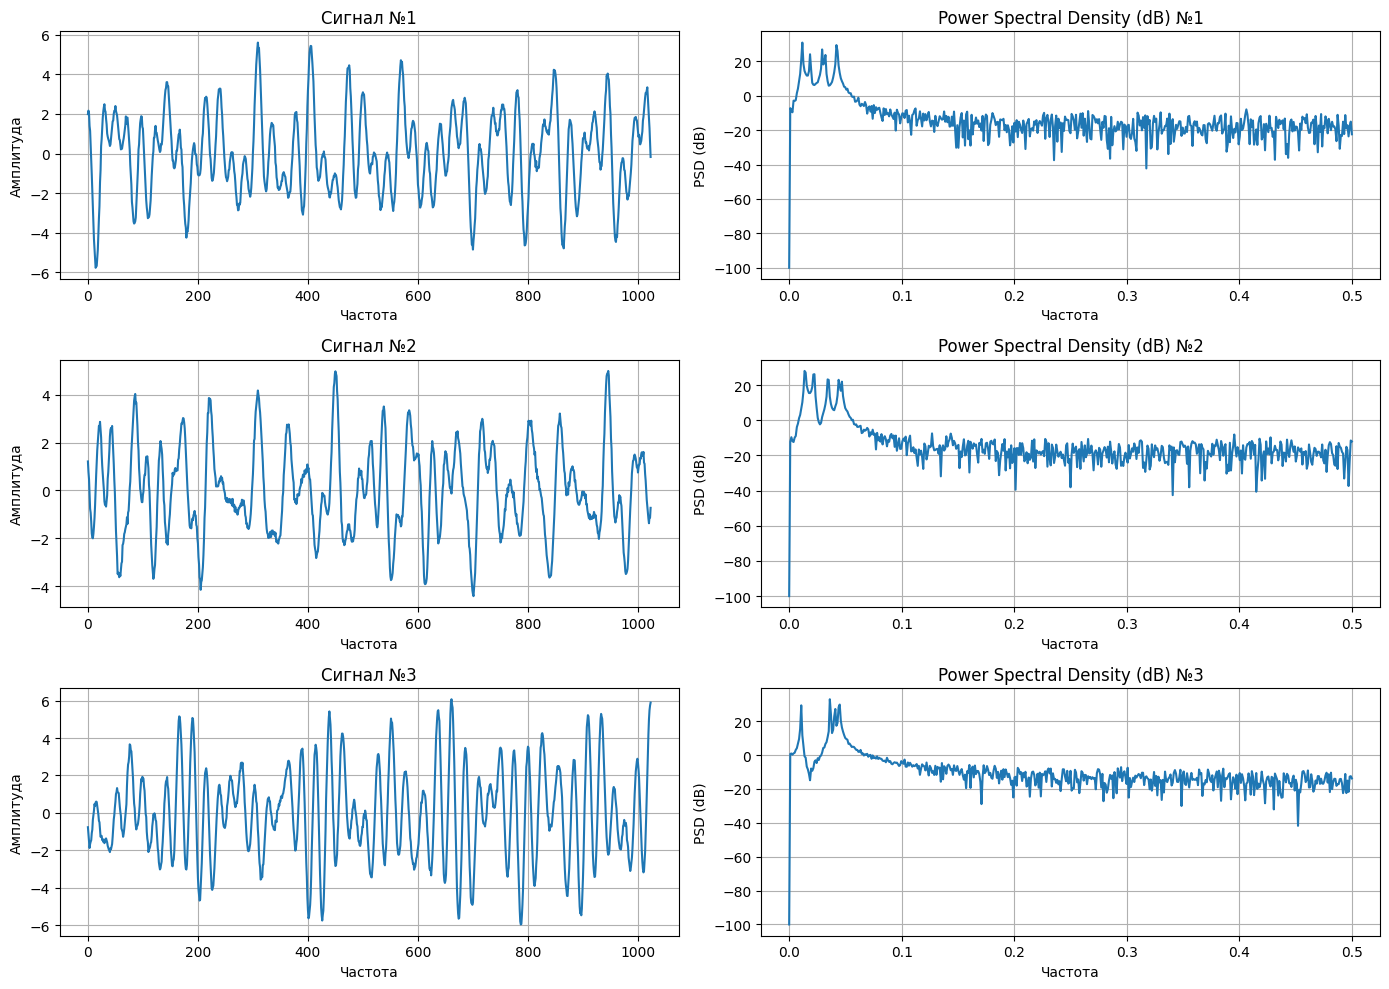

In [6]:
# Генерация обучающей выборки для PSD
print("Генерация обучающей выборки для PSD...")

X_train_psd = np.array([generate_signal() for _ in range(5 * N)])

# periodogram возвращает частоты и плотности мощности
y_train_psd = []

for sig in X_train_psd:
    freqs, psd = signal.periodogram(sig, fs=1.0, scaling="density")
    psd_db = 10 * np.log10(psd + 1e-10)
    y_train_psd.append(psd_db)

y_train_psd = np.array(y_train_psd, dtype=np.float32)

print(f"Форма X_train_psd: {X_train_psd.shape}")
print(f"Форма y_train_psd: {y_train_psd.shape}")
print()
print(f"Длина входа: {X_train_psd.shape[1]}")
print(f"Длина выхода: {y_train_psd.shape[1]}")

fig, axes = plt.subplots(3, 2, figsize=(14, 10))

for i in range(3):
    # Исходный сигнал
    axes[i, 0].plot(X_train_psd[i])
    axes[i, 0].set_title(f"Сигнал №{i+1}")
    axes[i, 0].set_xlabel("Частота")
    axes[i, 0].set_ylabel("Амплитуда")
    axes[i, 0].grid(True)

    # PSD в dB
    freqs, _ = signal.periodogram(X_train_psd[i], fs=1.0, scaling="density")
    axes[i, 1].plot(freqs, y_train_psd[i])
    axes[i, 1].set_title(f"Power Spectral Density (dB) №{i+1}")
    axes[i, 1].set_xlabel("Частота")
    axes[i, 1].set_ylabel("PSD (dB)")
    axes[i, 1].grid(True)

plt.tight_layout()
plt.show()

### Соберите и обучите нейросеть для предсказания спектральной плотности мощности

*Подсказка: для входа 1024 выход будет 512*


Модель PSDTransformer:
Общее количество параметров: 9,192,961

Запуск процедуры обучения...


Эпоха 1/25: 100%|██████████| 157/157 [00:08<00:00, 19.26it/s, текущая ошибка=55.4]


Средняя ошибка: 144.538469


Эпоха 2/25: 100%|██████████| 157/157 [00:07<00:00, 19.65it/s, текущая ошибка=42.2]


Средняя ошибка: 49.677283


...

Средняя ошибка: 32.627077


Эпоха 24/25: 100%|██████████| 157/157 [00:10<00:00, 14.93it/s, текущая ошибка=37.3]


Средняя ошибка: 32.432040


Эпоха 25/25: 100%|██████████| 157/157 [00:11<00:00, 14.05it/s, текущая ошибка=32.2]


Средняя ошибка: 32.214626


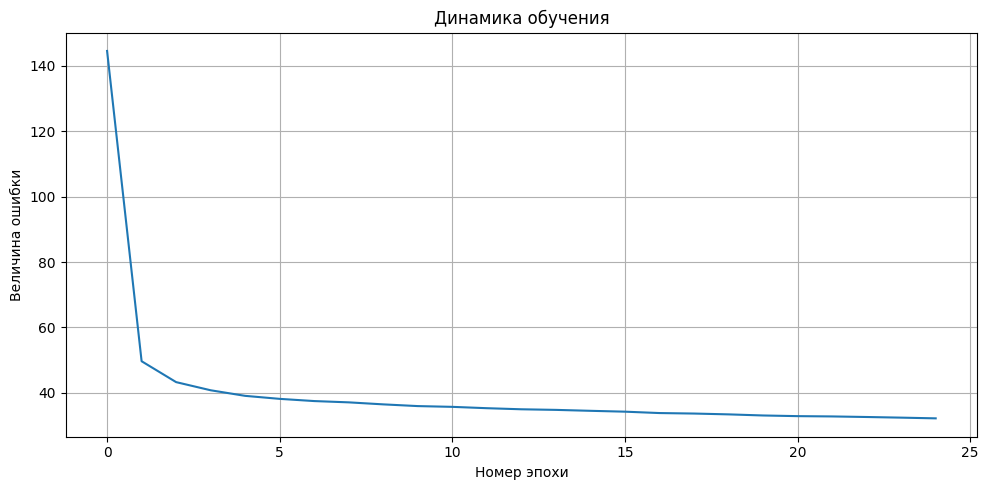


Финальная ошибка: 32.214626
Улучшение за обучение: 77.7%


In [7]:
class PSDTransformer(nn.Module):
    def __init__(self, input_size=SIGNAL_LENGTH, output_size=513):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 2048),
            nn.BatchNorm1d(2048),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(2048, 2048),
            nn.BatchNorm1d(2048),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(2048, 1024),
            nn.BatchNorm1d(1024),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(512, output_size),
        )

    def forward(self, input_signal):
        return self.network(input_signal)


class PSDTrainingData(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, index):
        return self.X[index], self.y[index]


psd_dataset = PSDTrainingData(X_train_psd, y_train_psd)
data_loader = DataLoader(psd_dataset, batch_size=BATCH_SIZE, shuffle=True)

model = PSDTransformer().to(DEVICE)
loss_function = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"\nМодель PSDTransformer:")
print(
    f"Общее количество параметров: " f"{sum(p.numel() for p in model.parameters()):,}"
)
print("\nЗапуск процедуры обучения...")

TOTAL_TRAINING_EPOCHS = 25
performance_history = train_model(
    model, data_loader, loss_function, optimizer, TOTAL_TRAINING_EPOCHS, DEVICE
)

plt.figure(figsize=(10, 5))

plt.plot(performance_history)
plt.xlabel("Номер эпохи")
plt.ylabel("Величина ошибки")
plt.title("Динамика обучения")
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"\nФинальная ошибка: {performance_history[-1]:.6f}")
print(
    f"Улучшение за обучение: "
    f"{(performance_history[0] - performance_history[-1])/performance_history[0]*100:.1f}%"
)

### Провалидируйте свое решение

*Примечание: Для сдачи достаточно качественного соответствия по форме спектра с пакетным решением*

In [8]:
def access_model(correlation):
    quality = "ПЛОХО - нужна другая модель"

    if correlation > 0.90:
        quality = "ПРЕВОСХОДНО"
    elif correlation > 0.80:
        quality = "ОТЛИЧНО"
    elif correlation > 0.70:
        quality = "ХОРОШО"
    elif correlation > 0.60:
        quality = "УДОВЛЕТВОРИТЕЛЬНО"

    return quality

C:\Users\ilyar\AppData\Local\Temp\ipykernel_19220\1587645572.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i, 1].legend()
C:\Users\ilyar\AppData\Local\Temp\ipykernel_19220\1587645572.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i, 2].legend()


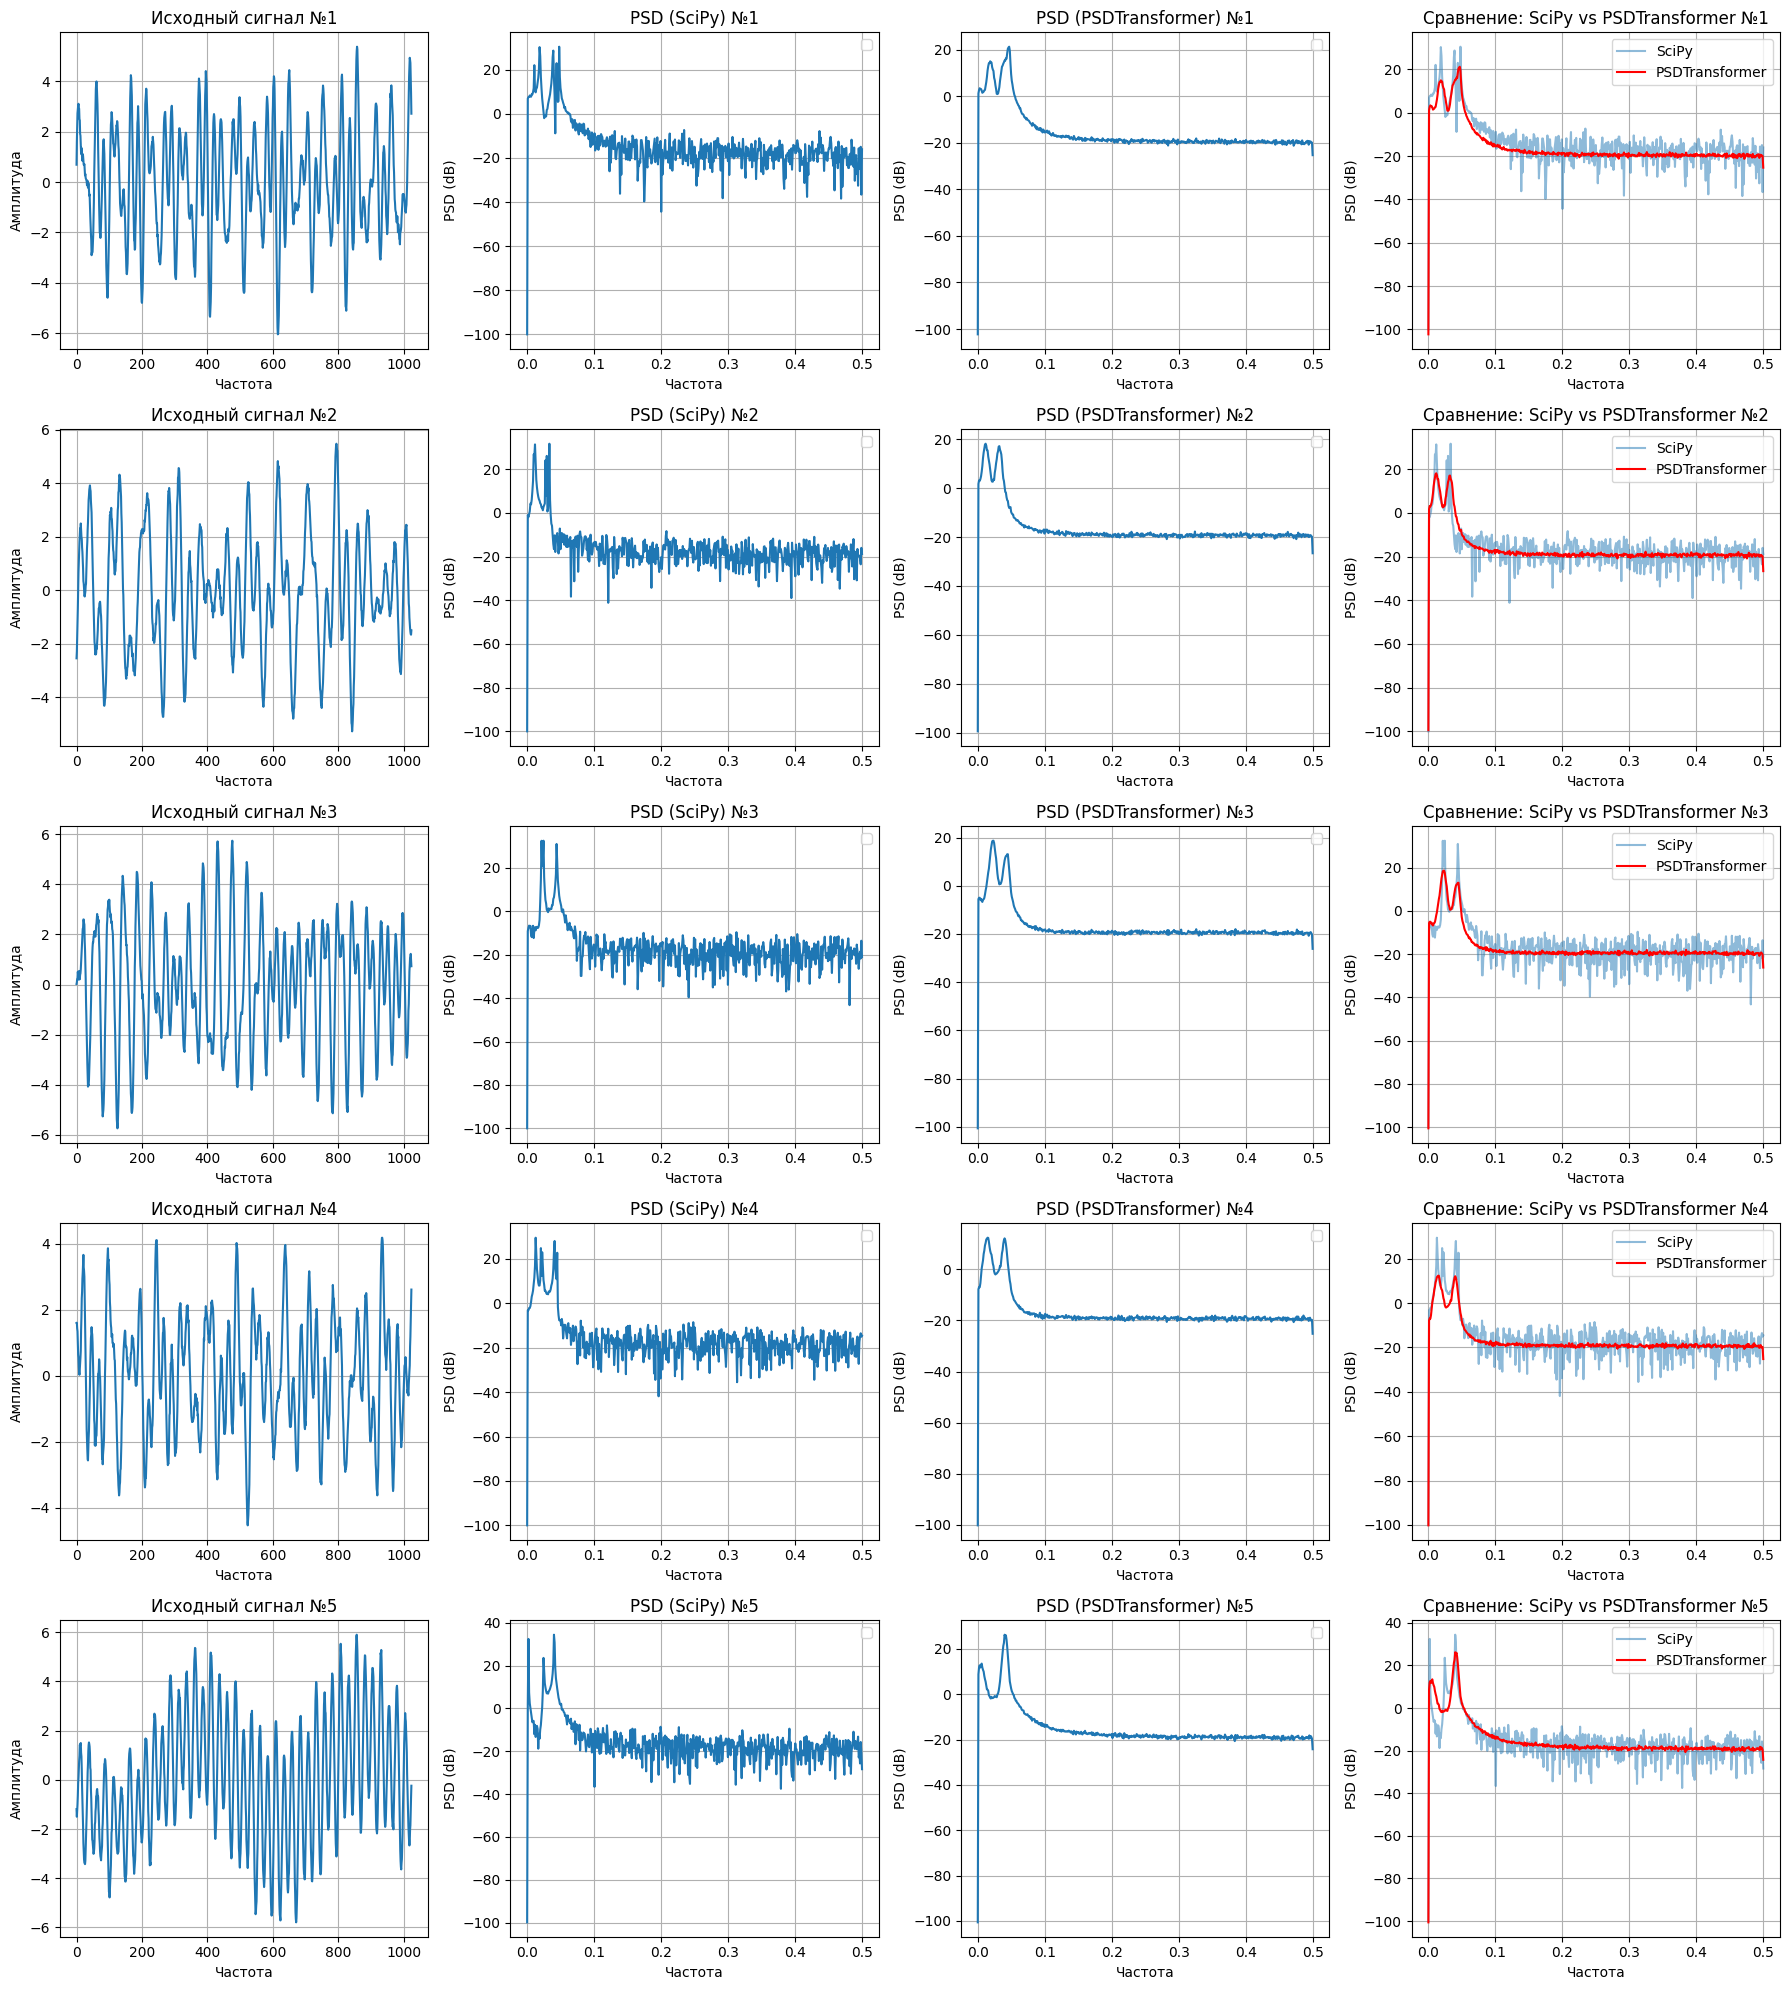


Сравнение PSD: Scipy vs PSDTransformer

Тестовый сигнал №1:
  MSE: 33.2709
  MAE: 1.3514
  Корреляция: 0.704821
  Оценка модели: ХОРОШО

Тестовый сигнал №2:
  MSE: 29.7218
  MAE: -0.1372
  Корреляция: 0.664966
  Оценка модели: УДОВЛЕТВОРИТЕЛЬНО

Тестовый сигнал №3:
  MSE: 35.0154
  MAE: -0.1351
  Корреляция: 0.698330
  Оценка модели: УДОВЛЕТВОРИТЕЛЬНО

Тестовый сигнал №4:
  MSE: 31.3603
  MAE: 0.7116
  Корреляция: 0.650324
  Оценка модели: УДОВЛЕТВОРИТЕЛЬНО

Тестовый сигнал №5:
  MSE: 34.4752
  MAE: -0.8974
  Корреляция: 0.701233
  Оценка модели: ХОРОШО

Средние метрики:
  Средний MSE: 997.6833
  Средний MAE: 913.7621
  Средняя корреляция: 0.683935
  Средняя оценка модели: УДОВЛЕТВОРИТЕЛЬНО


In [9]:
# Сравним на 5 сгенерированных сигналах
n_test = 5
test_signals = np.array([generate_signal() for _ in range(n_test)])

model.eval()
with torch.no_grad():
    test_tensor = torch.tensor(test_signals, dtype=torch.float32).to(DEVICE)
    psd_predictions = model(test_tensor).cpu().numpy()

# Вычисляем PSD с помощью Scipy
psd_scipy = []
freqs_list = []

for sig in test_signals:
    freqs, psd = signal.periodogram(sig, fs=1.0, scaling="density")
    psd_db = 10 * np.log10(psd + 1e-10)
    psd_scipy.append(psd_db)
    freqs_list.append(freqs)

psd_scipy = np.array(psd_scipy)

fig, axes = plt.subplots(n_test, 4, figsize=(18, 4 * n_test))

for i in range(n_test):
    axes[i, 0].plot(test_signals[i])
    axes[i, 0].set_title(f"Исходный сигнал №{i+1}")
    axes[i, 0].set_xlabel("Частота")
    axes[i, 0].set_ylabel("Амплитуда")
    axes[i, 0].grid(True)

    axes[i, 1].plot(freqs_list[i], psd_scipy[i])
    axes[i, 1].set_title(f"PSD (SciPy) №{i+1}")
    axes[i, 1].set_xlabel("Частота")
    axes[i, 1].set_ylabel("PSD (dB)")
    axes[i, 1].grid(True)
    axes[i, 1].legend()

    axes[i, 2].plot(
        freqs_list[i],
        psd_predictions[i],
    )
    axes[i, 2].set_title(f"PSD (PSDTransformer) №{i+1}")
    axes[i, 2].set_xlabel("Частота")
    axes[i, 2].set_ylabel("PSD (dB)")
    axes[i, 2].grid(True)
    axes[i, 2].legend()

    axes[i, 3].plot(
        freqs_list[i],
        psd_scipy[i],
        linewidth=1.5,
        alpha=0.5,
        label="SciPy",
    )
    axes[i, 3].plot(
        freqs_list[i], psd_predictions[i], "r", linewidth=1.5, label="PSDTransformer"
    )
    axes[i, 3].set_title(f"Сравнение: SciPy vs PSDTransformer №{i+1}")
    axes[i, 3].set_xlabel("Частота")
    axes[i, 3].set_ylabel("PSD (dB)")
    axes[i, 3].grid(True)
    axes[i, 3].legend()

plt.tight_layout()
plt.show()

print("\nСравнение PSD: Scipy vs PSDTransformer\n")
for i in range(n_test):
    # MSE
    mse_real = np.mean((psd_scipy[i] - psd_predictions[i]) ** 2)

    # MAE
    mse_imag = np.mean(psd_scipy[i] - psd_predictions[i])

    # Корреляция
    correlation = np.corrcoef(np.abs(psd_scipy[i]), np.abs(psd_predictions[i]))[0, 1]

    print(f"Тестовый сигнал №{i+1}:")
    print(f"  MSE: {mse_real:.4f}")
    print(f"  MAE: {mse_imag:.4f}")
    print(f"  Корреляция: {correlation:.6f}")
    print(f"  Оценка модели: {access_model(correlation)}")
    print()

# Среднее по всем тестовым сигналам
avg_mse = np.mean(
    [np.mean((psd_scipy[i] - psd_predictions[i]) ** 2) for i in range(n_test)]
)

avg_mae = np.mean([np.mean(psd_scipy[i] - psd_predictions[i]) for i in range(n_test)])

avg_correlation = np.mean(
    [
        np.corrcoef(np.abs(psd_scipy[i]), np.abs(psd_predictions[i]))[0, 1]
        for i in range(n_test)
    ]
)

print(f"Средние метрики:")
print(f"  Средний MSE: {avg_mse_real:.4f}")
print(f"  Средний MAE: {avg_mse_imag:.4f}")
print(f"  Средняя корреляция: {avg_correlation:.6f}")
print(f"  Средняя оценка модели: {access_model(avg_correlation)}")